In [1]:
import pandas as pd
from pathlib import Path
import numpy as np
import re
from itertools import product
from scipy.stats import permutation_test
from tqdm import tqdm
from matplotlib import pyplot as plt
import seaborn as sns
import os

In [2]:
# Files with results
data = None
for result_folder in ["nested_cv_leakage_results", "scaling_leakage_results"]:
    result_files = list(Path(result_folder).glob("*.csv"))

    # Compile files into one dataframe

    for file in result_files:
        df = pd.read_csv(file)
        df = df.drop(columns=["acc_leakage","acc_correct"], errors="ignore")
        if "nested" in result_folder:
            df["validation"] = "nested_cv"
        else:
            df["validation"] = "train_test"
        if df.isna().any().any():
            print(f"Warning: NaN values found in {file}")
            print(file)
            print(df[df.isna().any(axis=1)])
        if data is None:
            data = df
        else:
            data = pd.concat([data, df])


data["uar_diff"] = data["uar_leakage"] - data["uar_correct"]

# Showing the result table
data.head() # [["dataset", "scaler", "classifier", "stratify", f"{metric}_diff"]]

,dataset,scaler,stratify,classifier,seed,uar_correct,uar_leakage,validation,uar_diff
0,svd,MaxAbsScaler,True,svm,100,0.833161,0.829873,nested_cv,-0.003287
1,svd,MaxAbsScaler,True,knn,100,0.715287,0.720917,nested_cv,0.005630
2,svd,MaxAbsScaler,True,gaussianNB,100,0.660875,0.660875,nested_cv,0.000000
3,svd,MaxAbsScaler,True,lda,100,0.826780,0.826780,nested_cv,0.000000
4,svd,MaxAbsScaler,True,qda,100,0.741181,0.742665,nested_cv,0.001484


In [3]:
# Dictionary to replace temporary names for the ones being published
CLF_RENAME = {
    "adaboost":"\\gls{AB}",
    "dt": "\\gls{DT}",
    "gaussianNB": "\\gls{GNB}",
    "process": "\\gls{GP}",
    "knn": "\\gls{KNN}",
    "lda": "\\gls{LDA}",
    "mlp": "\\gls{MLP}",
    "qda": "\\gls{QDA}",
    "rf": "\\gls{RF}",
    "svm": "\\gls{SVM}"
}

OTHER_RENAME = {
    "svd": "\\gls{SVD}",
    "voiced": "\\gls{VOICED}",
    "MaxAbsScaler": "MaxAbs scaling",
    "MinMaxScaler": "MinMax scaling",
    "StandardScaler": "standard scaling",
    "RobustScaler": "robust scaling",
    "QuantileTransformer": "quantile transformation",
    "train_test": "Train-test split",
    "nested_cv": "Nested CV"
}

In [4]:
data.groupby(["dataset", "scaler", "classifier", "stratify", "validation"], as_index=False).agg({
  "seed": "count"
})["seed"].unique()

array([1000])

  dataset          scaler classifier  stratify validation      leakage  \
0     SVD  MaxAbs scaling        SVM      True  Nested CV  uar_leakage   
1     SVD  MaxAbs scaling        KNN      True  Nested CV  uar_leakage   
2     SVD  MaxAbs scaling        GNB      True  Nested CV  uar_leakage   
3     SVD  MaxAbs scaling        LDA      True  Nested CV  uar_leakage   
4     SVD  MaxAbs scaling        QDA      True  Nested CV  uar_leakage   

        UAR  
0  0.829873  
1  0.720917  
2  0.660875  
3  0.826780  
4  0.742665  


<Figure size 1000x1000 with 0 Axes>

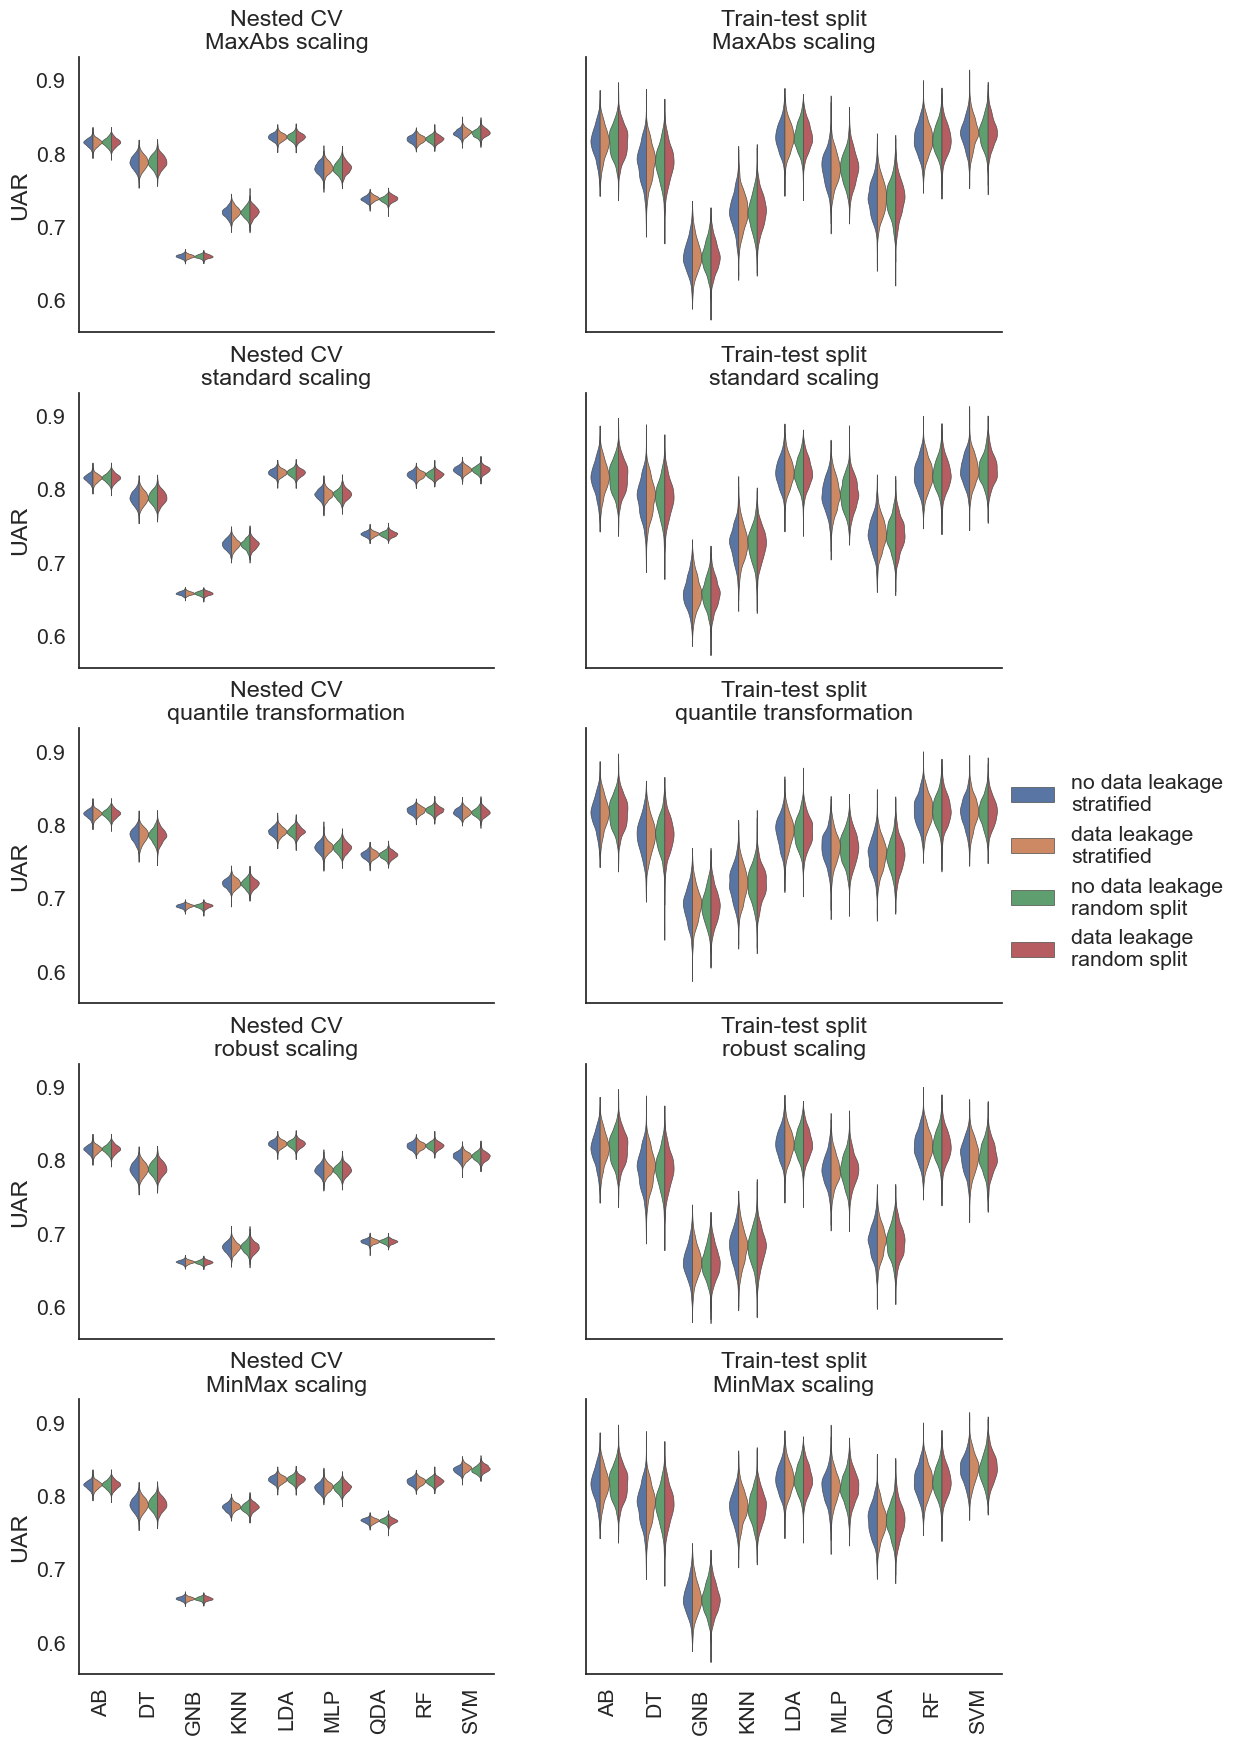

<Figure size 1000x1000 with 0 Axes>

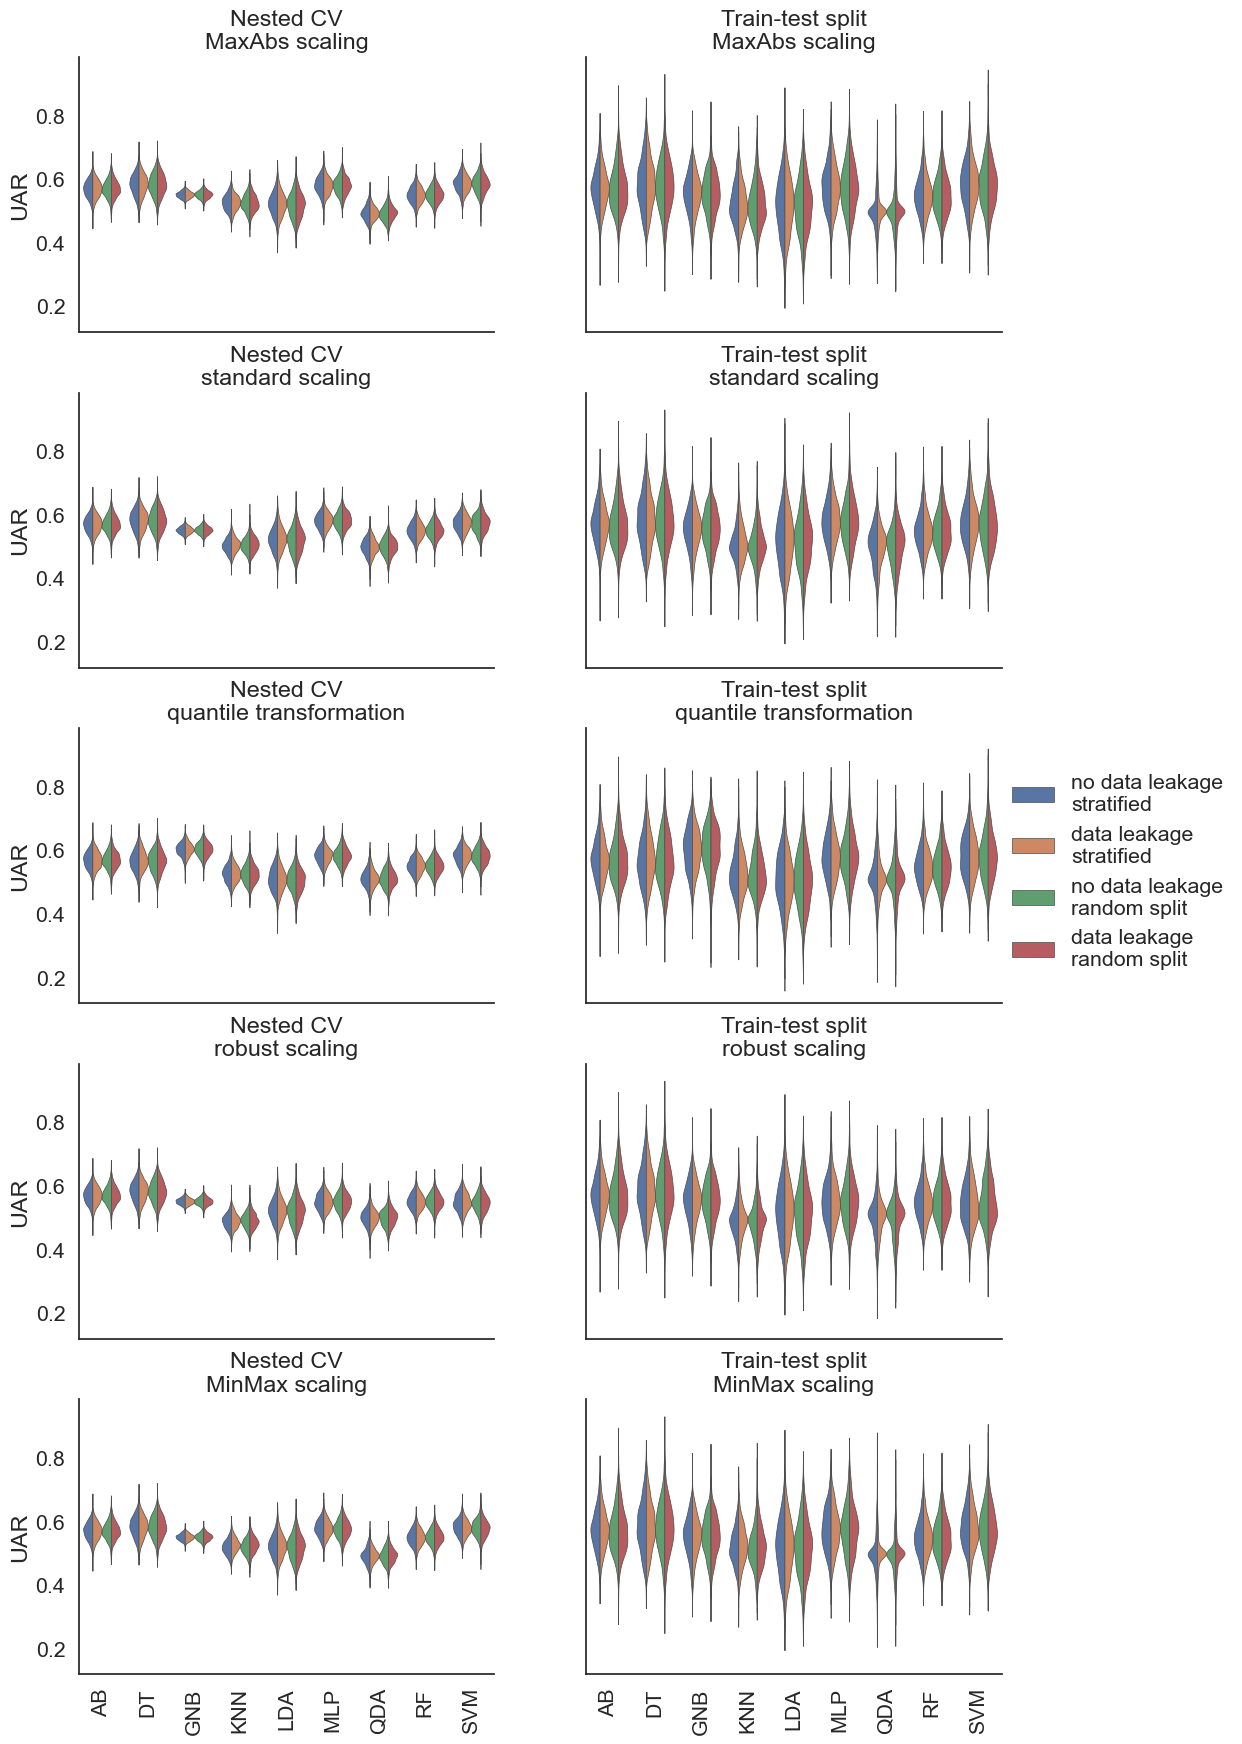

In [5]:
# Get the best results for each dataset, scaler, classifier, stratify and validation method

vis_data = data.melt(
    id_vars=[
        "dataset",
        "scaler",
        "classifier",
        "stratify",
        "validation"
    ], value_vars=["uar_leakage", "uar_correct"], var_name="leakage", value_name="UAR")
vis_data = vis_data.replace({
    "classifier": {
        "adaboost":"AB",
        "dt": "DT",
        "gaussianNB": "GNB",
        "knn": "KNN",
        "lda": "LDA",
        "mlp": "MLP",
        "qda": "QDA",
        "rf": "RF",
        "svm": "SVM"
    },
    "dataset": {"svd": "SVD", "voiced": "VOICED"},
    "scaler": OTHER_RENAME,
    "validation": OTHER_RENAME,

})
print(vis_data.head())

sns.set(font_scale=1.4)
sns.set_style("white")

for dataset in vis_data["dataset"].unique():
    tmp = vis_data[vis_data["dataset"] == dataset].drop(columns=["dataset"])

    plt.figure(figsize=(10, 10))
    tmp["leakage"] = tmp["leakage"].str.replace("uar_", "")
    tmp[""] = tmp["leakage"].str.replace("correct", "no leakage").str.replace("leakage", "data leakage") + "\n" \
        + tmp["stratify"].map({True: "stratified", False: "random split"})

    g = sns.catplot(
        data=tmp,
        x="classifier", hue="", y="UAR",
        row="scaler", col="validation",
        kind="violin",  split=True, inner=None,#"quart",
        sharey=True,
        hue_order=["no data leakage\nstratified", "data leakage\nstratified", "no data leakage\nrandom split", "data leakage\nrandom split"],
        # order x labels by alphabetical order of classifiers
        order=sorted(tmp["classifier"].unique()),
        aspect=1.5, height=3.5, density_norm="width", linewidth = 0.5
    )
    # rotate x labels
    g.set_xticklabels(g.axes.flat[-1].get_xticklabels(), rotation=90)
    # remove background and grid
    g.set_titles("{col_name}\n{row_name}")
    # remove x label
    g.set_axis_labels("", "UAR")
    plt.subplots_adjust(wspace=0.22, hspace=0.22)
    plt.savefig(f"results_{dataset}.pdf", bbox_inches="tight")

In [6]:

# Conducting a permutation test to see which mean differences are shifted from 0 with statistical significance at alpha = 0.05

# Metric used for determining the difference under null hypothesis
# (in this case, the null hypothesis states the mean value of the samples is the same)
stat_func = lambda a, b: np.mean(a - b)

# List of datasets and classifiers
dataset_list = list(data.dataset.unique())
classifier_list = list(data.classifier.unique())
validation_list = list(data.validation.unique())
scaler_list = list(data.scaler.unique())

# Conduct the test for each dataset-scaler-classifier-split type combination
combinations = product(validation_list,dataset_list, scaler_list, classifier_list, [True, False])
perm_results = pd.DataFrame(columns=["validation","dataset", "scaler", "stratify", "classifier", "p_value"])
for validation, dataset, scaler, clf, strat in tqdm(list(combinations)):
    row_filter = (data.validation == validation) & (data.dataset == dataset) & (data.scaler == scaler) & (data.classifier == clf) & (data.stratify == strat)
    try:
        result = permutation_test((data.loc[row_filter, "uar_leakage"], data.loc[row_filter, "uar_correct"]), statistic=stat_func,
                           permutation_type='samples', alternative='two-sided',
                           vectorized=False, n_resamples=10000, random_state=0)
        perm_results.loc[perm_results.shape[0], :] = [validation, dataset, scaler, strat, clf, result.pvalue]
    except ValueError:
        print(f"No data found for {dataset}, {scaler}, {clf}, {strat}")
        print(f"Continue with next combination")
        continue


# Decide the significance
perm_results["significant"] = perm_results.p_value < 0.05

# Show significantly shifted results
print(f"Total combinations tested: {perm_results.shape[0]}")
display(perm_results[perm_results.significant == True])

100%|██████████| 360/360 [11:17<00:00,  1.88s/it]

Total combinations tested: 360


,validation,dataset,scaler,stratify,classifier,p_value,significant
0,nested_cv,svd,MaxAbsScaler,True,svm,0.0002,True
1,nested_cv,svd,MaxAbsScaler,False,svm,0.0002,True
2,nested_cv,svd,MaxAbsScaler,True,knn,0.0002,True
4,nested_cv,svd,MaxAbsScaler,True,gaussianNB,0.0006,True
8,nested_cv,svd,MaxAbsScaler,True,qda,0.0002,True
...,...,...,...,...,...,...,...
343,train_test,voiced,MinMaxScaler,False,svm,0.014599,True
344,train_test,voiced,MinMaxScaler,True,knn,0.0014,True
345,train_test,voiced,MinMaxScaler,False,knn,0.0002,True
350,train_test,voiced,MinMaxScaler,True,qda,0.049795,True


In [7]:
data[(data.stratify == True) & (data.scaler == scaler) & (data.dataset == dataset)] \
    .groupby(["validation", "classifier"])[["uar_diff"]] \
    .agg(["max", "min", "mean", "std"]).columns

MultiIndex([('uar_diff',  'max'),
            ('uar_diff',  'min'),
            ('uar_diff', 'mean'),
            ('uar_diff',  'std')],
           )

In [8]:
test = data[(data.stratify == True) & (data.scaler == scaler) & (data.dataset == dataset)] \
    .groupby(["validation", "classifier"])["uar_diff"] \
    .agg(max="max", min="min", mean="mean", std="std")

In [9]:
for scaler, dataset in product(scaler_list, dataset_list):
    print(f"{scaler} and {dataset} results...")
    # Aggregated data for stratified and non-stratified splits. Showing only UAR as it is less biased for imbalanced datasets.
    temp_stratified = data[(data.stratify == True) & (data.scaler == scaler) & (data.dataset == dataset)].groupby(["validation", "classifier"])["uar_diff"].agg(q3=lambda x: x.quantile(0.75), q1=lambda x: x.quantile(0.25), mean="mean", std="std")
    temp_nonstratified = data[(data.stratify == False) & (data.scaler == scaler) & (data.dataset == dataset)].groupby(["validation", "classifier"])["uar_diff"].agg(q3=lambda x: x.quantile(0.75), q1=lambda x: x.quantile(0.25), mean="mean", std="std")
    #temp_combined = pd.concat([temp_nonstratified, temp_stratified], axis=1)
    temp_combined = temp_nonstratified.join(temp_stratified, lsuffix="_nonstrat", rsuffix="_strat").sort_index(ascending=[False,True])
    display(temp_combined)
    # make bold the highest absolute value in columns Max and Min and box the significant values based on permutation test
    temp_combined = temp_combined.round(decimals=3).style\
                                                    .apply(lambda col: np.where(col.abs() == col.abs().max(), 'textbf:--rwrap;', ''),
                                                                       subset=pd.IndexSlice[pd.IndexSlice["nested_cv",:], ['q3_nonstrat', 'q1_nonstrat', 'q3_strat', 'q1_strat']],
                                                                       axis=0) \
                                                    .apply(lambda col: np.where(col.abs() == col.abs().max(), 'textbf:--rwrap;', ''),
                                                                       subset=pd.IndexSlice[pd.IndexSlice["train_test",:], ['q3_nonstrat', 'q1_nonstrat', 'q3_strat', 'q1_strat']],
                                                                       axis=0) \
                                                    .apply(lambda row: ['fbox:--rwrap;' if
                                                                       perm_results[
                                                                           (perm_results.validation == row.name[0]) &
                                                                           (perm_results.dataset == dataset) &
                                                                           (perm_results.scaler == scaler) &
                                                                           (perm_results.classifier == row.name[1]) &
                                                                           (perm_results.stratify == True)
                                                                       ]["significant"].values[0]
                                                                       else '' for _ in row],
                                                                       subset=pd.IndexSlice[pd.IndexSlice[:, :], "mean_strat"],
                                                                       axis=1) \
                                                    .apply(lambda row: ['fbox:--rwrap;' if
                                                                       perm_results[
                                                                           (perm_results.validation == row.name[0]) &
                                                                           (perm_results.dataset == dataset) &
                                                                           (perm_results.scaler == scaler) &
                                                                           (perm_results.classifier == row.name[1]) &
                                                                           (perm_results.stratify == False)
                                                                       ]["significant"].values[0]
                                                                       else '' for _ in row],
                                                                       subset=pd.IndexSlice[pd.IndexSlice[:, :], "mean_nonstrat"],
                                                                       axis=1) \
                                                    .format(precision=3)

    # Saving the results as tex tables
    # Adding a table definition
    table_tex = [r"\begin{table}[t]", r"\centering"]

    # Append the actual table with results
    table_tex += temp_combined.to_latex(#float_format="%.3f",
                                        column_format="llcccccccc",
                                        #escape=False,
                                        hrules=True,
                                        ).split("\n")

    print(table_tex)

    # Change the multicolumn and split it to Random split and Stratified split
    table_tex[4] = r"& & \multicolumn{4}{c}{Random split} & \multicolumn{4}{c}{Stratified split} \\"

    # Change the header to also include Model
    table_tex[5] = r"& Model & Q3 & Q1 & $\mu$ & $\sigma$ & Q3 & Q1 & $\mu$ & $\sigma$ \\"

    # Delete the dataset and classifier header
    table_tex.pop(6)

    #table_tex.pop(3)

    # Delete the extra cline
    #table_tex.pop(-4)

    # add extra midrule after 14th line (after SVM classifier)
    table_tex.insert(15, r"\midrule")


    # Add the end of table to the end
    table_tex[-1] = r"\caption{Data leakage results for " + OTHER_RENAME[scaler] + r" on " + OTHER_RENAME[dataset] + r" dataset.}"
    table_tex.append(r"\label{tab:" + scaler.lower() + dataset.lower() + r"}")
    table_tex.append(r"\end{table}")


    # Convert the list to a string
    table_tex = "\n".join(table_tex)

    # Rotate the name of the datasets
    table_tex = (table_tex.replace("[t]", "")
                          .replace("train_test", r"\rotatebox{90}{" + OTHER_RENAME["train_test"] + "}")
                          .replace("nested_cv", r"\rotatebox{90}{" + OTHER_RENAME["nested_cv"] + "}"))

    # Rename all classifiers
    for key, value in CLF_RENAME.items():
        table_tex = table_tex.replace(key, value)

    # Switch \cline for \midrule
    table_tex = table_tex.replace(r"\cline{1-10}", r"\midrule")

    # Save as tex file
    with open(f"{scaler}_{dataset}_results.tex", "w") as f:
        f.write(table_tex)


MaxAbsScaler and svd results...


q3_nonstrat  q1_nonstrat  mean_nonstrat  std_nonstrat  \
validation classifier                                                          
train_test adaboost       0.000000     0.000000   0.000000e+00      0.000000   
           dt             0.000000     0.000000   0.000000e+00      0.000000   
           gaussianNB     0.000000     0.000000  -4.800292e-05      0.000910   
           knn            0.012254    -0.008783   2.008667e-03      0.016695   
           lda            0.000000     0.000000   0.000000e+00      0.000000   
           mlp            0.013554    -0.012751   8.542673e-05      0.019550   
           qda            0.006235    -0.004760   8.395584e-04      0.009975   
           rf             0.000000     0.000000  -1.232215e-05      0.000563   
           svm            0.005753    -0.003716   1.328897e-03      0.009459   
nested_cv  adaboost       0.000000     0.000000   0.000000e+00      0.000000   
           dt             0.000000     0.000000  -4.950495e-07      0.000016   
           gaussianNB     0.000000     0.000000  -1.328837e-05      0.000418   
           knn            0.005227    -0.004710   2.746350e-04      0.007332   
           lda            0.000000     0.000000   0.000000e+00      0.000000   
           mlp            0.006876    -0.006150   3.873417e-04      0.009297   
           qda            0.003958    -0.001371   1.416926e-03      0.004093   
           rf             0.000000     0.000000  -7.133074e-07      0.000456   
           svm            0.004071    -0.001383   1.327515e-03      0.004354   

                       q3_strat  q1_strat    mean_strat  std_strat  
validation classifier                                               
train_test adaboost    0.000000  0.000000  0.000000e+00   0.000000  
           dt          0.000000  0.000000  0.000000e+00   0.000000  
           gaussianNB  0.000000  0.000000 -2.674706e-05   0.000703  
           knn         0.011383 -0.010049  7.775201e-04   0.016828  
           lda         0.000000  0.000000  0.000000e+00   0.000000  
           mlp         0.011460 -0.014069 -1.027752e-03   0.019853  
           qda         0.006416 -0.004793  1.078618e-03   0.009415  
           rf          0.000000  0.000000 -5.434447e-05   0.000959  
           svm         0.006339 -0.003788  1.480751e-03   0.009477  
nested_cv  adaboost    0.000000  0.000000  0.000000e+00   0.000000  
           dt          0.000000  0.000000  5.102041e-07   0.000016  
           gaussianNB  0.000000  0.000000 -3.720300e-05   0.000390  
           knn         0.005908 -0.004012  1.019599e-03   0.007327  
           lda         0.000000  0.000000  0.000000e+00   0.000000  
           mlp         0.006598 -0.005215  7.123522e-04   0.008813  
           qda         0.003534 -0.001607  1.098760e-03   0.003837  
           rf          0.000000  0.000000 -2.957149e-05   0.000542  
           svm         0.004269 -0.001273  1.447499e-03   0.004344

['\\begin{table}[t]', '\\centering', '\\begin{tabular}{llcccccccc}', '\\toprule', ' &  & q3_nonstrat & q1_nonstrat & mean_nonstrat & std_nonstrat & q3_strat & q1_strat & mean_strat & std_strat \\\\', 'validation & classifier &  &  &  &  &  &  &  &  \\\\', '\\midrule', '\\multirow[c]{9}{*}{train_test} & adaboost & 0.000 & 0.000 & 0.000 & 0.000 & 0.000 & 0.000 & 0.000 & 0.000 \\\\', ' & dt & 0.000 & 0.000 & 0.000 & 0.000 & 0.000 & 0.000 & 0.000 & 0.000 \\\\', ' & gaussianNB & 0.000 & 0.000 & -0.000 & 0.001 & 0.000 & 0.000 & -0.000 & 0.001 \\\\', ' & knn & 0.012 & -0.009 & \\fbox{0.002} & 0.017 & \\textbf{0.011} & -0.010 & 0.001 & 0.017 \\\\', ' & lda & 0.000 & 0.000 & 0.000 & 0.000 & 0.000 & 0.000 & 0.000 & 0.000 \\\\', ' & mlp & \\textbf{0.014} & \\textbf{-0.013} & 0.000 & 0.020 & \\textbf{0.011} & \\textbf{-0.014} & -0.001 & 0.020 \\\\', ' & qda & 0.006 & -0.005 & \\fbox{0.001} & 0.010 & 0.006 & -0.005 & \\fbox{0.001} & 0.009 \\\\', ' & rf & 0.000 & 0.000 & -0.000 & 0.001 & 0.000 & 0.0

q3_nonstrat  q1_nonstrat  mean_nonstrat  std_nonstrat  \
validation classifier                                                          
train_test adaboost       0.000000     0.000000       0.000000      0.000000   
           dt             0.000000     0.000000       0.000000      0.000000   
           gaussianNB     0.000000     0.000000      -0.000031      0.000699   
           knn            0.031250    -0.039219      -0.002777      0.065235   
           lda            0.000000     0.000000       0.000000      0.000000   
           mlp            0.034402    -0.035714      -0.001146      0.062572   
           qda            0.044118    -0.036752       0.004201      0.081104   
           rf             0.000000     0.000000       0.000000      0.000000   
           svm            0.025000    -0.029412      -0.000670      0.055376   
nested_cv  adaboost       0.000000     0.000000       0.000000      0.000000   
           dt             0.000000     0.000000       0.000000      0.000000   
           gaussianNB     0.000000     0.000000      -0.000012      0.000582   
           knn            0.017714    -0.019587      -0.000740      0.028175   
           lda            0.000000     0.000000       0.000000      0.000000   
           mlp            0.017462    -0.016716      -0.000055      0.025776   
           qda            0.025252    -0.017726       0.002809      0.032598   
           rf             0.000000     0.000000       0.000000      0.000000   
           svm            0.013699    -0.016944      -0.001261      0.025200   

                       q3_strat  q1_strat  mean_strat  std_strat  
validation classifier                                             
train_test adaboost    0.000000  0.000000    0.000000   0.000000  
           dt          0.000000  0.000000    0.000000   0.000000  
           gaussianNB  0.000000  0.000000   -0.000017   0.001937  
           knn         0.025000 -0.041667   -0.002058   0.062280  
           lda         0.000000  0.000000    0.000000   0.000000  
           mlp         0.033333 -0.033333   -0.001892   0.056620  
           qda         0.050000 -0.033333    0.004117   0.076606  
           rf          0.000000  0.000000    0.000000   0.000000  
           svm         0.025000 -0.033333   -0.001192   0.052719  
nested_cv  adaboost    0.000000  0.000000    0.000000   0.000000  
           dt          0.000000  0.000000    0.000000   0.000000  
           gaussianNB  0.000000  0.000000   -0.000005   0.000368  
           knn         0.016300 -0.019091   -0.001569   0.027096  
           lda         0.000000  0.000000    0.000000   0.000000  
           mlp         0.015704 -0.018300   -0.000840   0.027402  
           qda         0.022263 -0.020736    0.000305   0.033043  
           rf          0.000000  0.000000    0.000000   0.000000  
           svm         0.013501 -0.017251   -0.001507   0.023966

['\\begin{table}[t]', '\\centering', '\\begin{tabular}{llcccccccc}', '\\toprule', ' &  & q3_nonstrat & q1_nonstrat & mean_nonstrat & std_nonstrat & q3_strat & q1_strat & mean_strat & std_strat \\\\', 'validation & classifier &  &  &  &  &  &  &  &  \\\\', '\\midrule', '\\multirow[c]{9}{*}{train_test} & adaboost & 0.000 & 0.000 & 0.000 & 0.000 & 0.000 & 0.000 & 0.000 & 0.000 \\\\', ' & dt & 0.000 & 0.000 & 0.000 & 0.000 & 0.000 & 0.000 & 0.000 & 0.000 \\\\', ' & gaussianNB & 0.000 & 0.000 & -0.000 & 0.001 & 0.000 & 0.000 & -0.000 & 0.002 \\\\', ' & knn & 0.031 & \\textbf{-0.039} & -0.003 & 0.065 & 0.025 & \\textbf{-0.042} & -0.002 & 0.062 \\\\', ' & lda & 0.000 & 0.000 & 0.000 & 0.000 & 0.000 & 0.000 & 0.000 & 0.000 \\\\', ' & mlp & 0.034 & -0.036 & -0.001 & 0.063 & 0.033 & -0.033 & -0.002 & 0.057 \\\\', ' & qda & \\textbf{0.044} & -0.037 & 0.004 & 0.081 & \\textbf{0.050} & -0.033 & 0.004 & 0.077 \\\\', ' & rf & 0.000 & 0.000 & 0.000 & 0.000 & 0.000 & 0.000 & 0.000 & 0.000 \\\\', ' & sv

...

['\\begin{table}[t]', '\\centering', '\\begin{tabular}{llcccccccc}', '\\toprule', ' &  & q3_nonstrat & q1_nonstrat & mean_nonstrat & std_nonstrat & q3_strat & q1_strat & mean_strat & std_strat \\\\', 'validation & classifier &  &  &  &  &  &  &  &  \\\\', '\\midrule', '\\multirow[c]{9}{*}{train_test} & adaboost & 0.000 & 0.000 & 0.000 & 0.005 & 0.000 & 0.000 & -0.000 & 0.004 \\\\', ' & dt & 0.000 & 0.000 & \\fbox{-0.001} & 0.015 & 0.000 & 0.000 & \\fbox{-0.001} & 0.015 \\\\', ' & gaussianNB & 0.000 & 0.000 & -0.000 & 0.002 & 0.000 & 0.000 & -0.000 & 0.003 \\\\', ' & knn & 0.019 & -0.019 & -0.000 & 0.051 & 0.025 & -0.017 & \\fbox{0.003} & 0.050 \\\\', ' & lda & 0.000 & 0.000 & 0.000 & 0.000 & 0.000 & 0.000 & 0.000 & 0.000 \\\\', ' & mlp & 0.018 & -0.019 & -0.001 & 0.046 & 0.025 & -0.025 & 0.000 & 0.045 \\\\', ' & qda & \\textbf{0.035} & \\textbf{-0.036} & 0.002 & 0.076 & \\textbf{0.033} & \\textbf{-0.042} & 0.000 & 0.078 \\\\', ' & rf & 0.000 & 0.000 & 0.000 & 0.011 & 0.000 & 0.000 & -0

q3_nonstrat  q1_nonstrat  mean_nonstrat  std_nonstrat  \
validation classifier                                                          
train_test adaboost       0.000000     0.000000       0.000000      0.000000   
           dt             0.000000     0.000000       0.000000      0.000000   
           gaussianNB     0.000000     0.000000      -0.000053      0.000924   
           knn            0.008666    -0.007576       0.000448      0.013076   
           lda            0.000000     0.000000       0.000000      0.000000   
           mlp            0.010490    -0.008891       0.001123      0.014545   
           qda            0.005125    -0.005674      -0.000521      0.009952   
           rf             0.000000     0.000000       0.000020      0.001140   
           svm            0.006504    -0.002564       0.002376      0.009240   
nested_cv  adaboost       0.000000     0.000000       0.000000      0.000000   
           dt             0.000000     0.000000       0.000000      0.000000   
           gaussianNB     0.000000     0.000000      -0.000014      0.000418   
           knn            0.004877    -0.003026       0.001000      0.005767   
           lda            0.000000     0.000000       0.000000      0.000000   
           mlp            0.005292    -0.003874       0.000818      0.006651   
           qda            0.002094    -0.003140      -0.000552      0.004120   
           rf             0.000000     0.000000      -0.000014      0.000701   
           svm            0.005184    -0.000520       0.002386      0.004488   

                       q3_strat  q1_strat  mean_strat  std_strat  
validation classifier                                             
train_test adaboost    0.000000  0.000000    0.000000   0.000000  
           dt          0.000000  0.000000   -0.000029   0.000924  
           gaussianNB  0.000000  0.000000    0.000012   0.000784  
           knn         0.007730 -0.006416    0.000991   0.012528  
           lda         0.000000  0.000000    0.000000   0.000000  
           mlp         0.010204 -0.008735    0.001320   0.014749  
           qda         0.005102 -0.005025   -0.000344   0.008823  
           rf          0.000000  0.000000    0.000034   0.001444  
           svm         0.006339 -0.002551    0.002135   0.009161  
nested_cv  adaboost    0.000000  0.000000    0.000000   0.000000  
           dt          0.000000  0.000000    0.000005   0.000124  
           gaussianNB  0.000000  0.000000   -0.000043   0.000384  
           knn         0.004578 -0.002567    0.001009   0.005411  
           lda         0.000000  0.000000    0.000000   0.000000  
           mlp         0.005331 -0.003051    0.001013   0.006399  
           qda         0.002184 -0.002672   -0.000287   0.003622  
           rf          0.000000  0.000000   -0.000036   0.000723  
           svm         0.005091 -0.000221    0.002510   0.004134

['\\begin{table}[t]', '\\centering', '\\begin{tabular}{llcccccccc}', '\\toprule', ' &  & q3_nonstrat & q1_nonstrat & mean_nonstrat & std_nonstrat & q3_strat & q1_strat & mean_strat & std_strat \\\\', 'validation & classifier &  &  &  &  &  &  &  &  \\\\', '\\midrule', '\\multirow[c]{9}{*}{train_test} & adaboost & 0.000 & 0.000 & 0.000 & 0.000 & 0.000 & 0.000 & 0.000 & 0.000 \\\\', ' & dt & 0.000 & 0.000 & 0.000 & 0.000 & 0.000 & 0.000 & -0.000 & 0.001 \\\\', ' & gaussianNB & 0.000 & 0.000 & -0.000 & 0.001 & 0.000 & 0.000 & 0.000 & 0.001 \\\\', ' & knn & 0.009 & -0.008 & 0.000 & 0.013 & 0.008 & -0.006 & \\fbox{0.001} & 0.013 \\\\', ' & lda & 0.000 & 0.000 & 0.000 & 0.000 & 0.000 & 0.000 & 0.000 & 0.000 \\\\', ' & mlp & \\textbf{0.010} & \\textbf{-0.009} & \\fbox{0.001} & 0.015 & \\textbf{0.010} & \\textbf{-0.009} & \\fbox{0.001} & 0.015 \\\\', ' & qda & 0.005 & -0.006 & -0.001 & 0.010 & 0.005 & -0.005 & -0.000 & 0.009 \\\\', ' & rf & 0.000 & 0.000 & 0.000 & 0.001 & 0.000 & 0.000 & 0.000

q3_nonstrat  q1_nonstrat  mean_nonstrat  std_nonstrat  \
validation classifier                                                          
train_test adaboost       0.000000     0.000000       0.000052      0.004265   
           dt             0.000000     0.000000      -0.000031      0.005417   
           gaussianNB     0.000000     0.000000      -0.000046      0.000832   
           knn            0.035714    -0.018768       0.008565      0.061069   
           lda            0.000000     0.000000       0.000000      0.000000   
           mlp            0.028571    -0.031250      -0.001722      0.052583   
           qda            0.045810    -0.035354       0.005520      0.075860   
           rf             0.000000     0.000000       0.000161      0.004937   
           svm            0.018828    -0.029466      -0.004015      0.053214   
nested_cv  adaboost       0.000000     0.000000       0.000027      0.001991   
           dt             0.000000     0.000000       0.000056      0.002569   
           gaussianNB     0.000000     0.000000      -0.000020      0.000432   
           knn            0.024299    -0.009988       0.007052      0.026500   
           lda            0.000000     0.000000       0.000000      0.000000   
           mlp            0.013714    -0.017038      -0.001584      0.023081   
           qda            0.024419    -0.021126       0.001508      0.034575   
           rf             0.000000     0.000000       0.000130      0.003804   
           svm            0.015011    -0.018515      -0.001754      0.024088   

                       q3_strat  q1_strat    mean_strat  std_strat  
validation classifier                                               
train_test adaboost    0.000000  0.000000  3.333333e-05   0.001054  
           dt          0.000000  0.000000 -3.333333e-05   0.007577  
           gaussianNB  0.000000  0.000000 -1.110223e-19   0.001864  
           knn         0.033333 -0.025000  5.791667e-03   0.058053  
           lda         0.000000  0.000000  0.000000e+00   0.000000  
           mlp         0.025000 -0.025000  1.000000e-04   0.048638  
           qda         0.050000 -0.033333  4.808333e-03   0.076031  
           rf          0.000000  0.000000  2.000000e-04   0.010425  
           svm         0.025000 -0.025000 -2.091667e-03   0.052222  
nested_cv  adaboost    0.000000  0.000000  2.693060e-05   0.001143  
           dt          0.000000  0.000000 -2.015152e-05   0.002649  
           gaussianNB  0.000000  0.000000 -1.774194e-06   0.000383  
           knn         0.025670 -0.006683  8.809731e-03   0.025092  
           lda         0.000000  0.000000  0.000000e+00   0.000000  
           mlp         0.013333 -0.017273 -6.686168e-04   0.023467  
           qda         0.023944 -0.021752  1.525953e-04   0.034115  
           rf          0.000000  0.000000 -1.304448e-04   0.003436  
           svm         0.012344 -0.017808 -2.704330e-03   0.023400

['\\begin{table}[t]', '\\centering', '\\begin{tabular}{llcccccccc}', '\\toprule', ' &  & q3_nonstrat & q1_nonstrat & mean_nonstrat & std_nonstrat & q3_strat & q1_strat & mean_strat & std_strat \\\\', 'validation & classifier &  &  &  &  &  &  &  &  \\\\', '\\midrule', '\\multirow[c]{9}{*}{train_test} & adaboost & 0.000 & 0.000 & 0.000 & 0.004 & 0.000 & 0.000 & 0.000 & 0.001 \\\\', ' & dt & 0.000 & 0.000 & -0.000 & 0.005 & 0.000 & 0.000 & -0.000 & 0.008 \\\\', ' & gaussianNB & 0.000 & 0.000 & -0.000 & 0.001 & 0.000 & 0.000 & -0.000 & 0.002 \\\\', ' & knn & 0.036 & -0.019 & \\fbox{0.009} & 0.061 & 0.033 & -0.025 & \\fbox{0.006} & 0.058 \\\\', ' & lda & 0.000 & 0.000 & 0.000 & 0.000 & 0.000 & 0.000 & 0.000 & 0.000 \\\\', ' & mlp & 0.029 & -0.031 & -0.002 & 0.053 & 0.025 & -0.025 & 0.000 & 0.049 \\\\', ' & qda & \\textbf{0.046} & \\textbf{-0.035} & \\fbox{0.006} & 0.076 & \\textbf{0.050} & \\textbf{-0.033} & \\fbox{0.005} & 0.076 \\\\', ' & rf & 0.000 & 0.000 & 0.000 & 0.005 & 0.000 & 0.00

In [11]:
with open("results_tables.tex", "w") as outfile:
    Path("result_tables").mkdir(exist_ok=True)
    for file in Path(".").glob("*_results.tex"):
        with open(file, "r") as infile:
            outfile.write(infile.read())
            outfile.write("\n\n")
        file.rename(Path("result_tables").joinpath(file.name))


In [12]:
data.groupby(["validation", "scaler", "classifier", "stratify", "dataset"])[["uar_diff"]].agg(["mean"])

uar_diff
                                                               mean
validation scaler         classifier stratify dataset              
nested_cv  MaxAbsScaler   adaboost   False    svd      0.000000e+00
                                              voiced   0.000000e+00
                                     True     svd      0.000000e+00
                                              voiced   0.000000e+00
                          dt         False    svd     -4.950495e-07
...                                                             ...
train_test StandardScaler rf         True     voiced  -7.666667e-04
                          svm        False    svd      9.580478e-05
                                              voiced  -4.126355e-04
                                     True     svd      1.111626e-04
                                              voiced   1.491667e-03

[360 rows x 1 columns]

In [13]:
table = data.groupby(["validation", "scaler", "classifier", "stratify", "dataset"])["uar_diff"].agg(["mean","max","min","std"]).reset_index()

# get values with statistical significance
significant_results = perm_results[perm_results["significant"] == True]
# from data select only those rows which are significant
results_with_significance = table.merge(significant_results[["validation", "dataset", "scaler", "stratify", "classifier","p_value"]],
                                        on=["validation", "dataset", "scaler", "stratify", "classifier"],
                                        how="inner")
results_with_significance[(results_with_significance.scaler == "RobustScaler") & (results_with_significance.dataset == "voiced")].sort_values(by=["validation","mean"])

,validation,scaler,classifier,stratify,dataset,mean,max,min,std,p_value
34,nested_cv,RobustScaler,dt,False,voiced,-0.000914,0.054830,-0.056061,0.005920,0.0002
35,nested_cv,RobustScaler,dt,True,voiced,-0.000683,0.070000,-0.058030,0.007305,0.0046
33,nested_cv,RobustScaler,adaboost,True,voiced,-0.000213,0.019091,-0.052727,0.002736,0.008399
38,nested_cv,RobustScaler,qda,False,voiced,0.002928,0.137294,-0.118906,0.033709,0.006599
81,train_test,RobustScaler,svm,False,voiced,-0.004485,0.241667,-0.253125,0.039905,0.0002
76,train_test,RobustScaler,dt,True,voiced,-0.001350,0.208333,-0.191667,0.015409,0.0034
75,train_test,RobustScaler,dt,False,voiced,-0.001081,0.120192,-0.200000,0.015086,0.020598
77,train_test,RobustScaler,knn,True,voiced,0.003467,0.200000,-0.200000,0.049942,0.029197


# Results interpretation

## Statistics

In [62]:
data_grouped = data.groupby(["validation", "dataset", "scaler", "classifier", "stratify"])["uar_diff"].agg(q3=lambda x: x.quantile(0.75), mean_uar_diff="mean", q1=lambda x: x.quantile(0.25), std="std").reset_index()
display(data_grouped)

,validation,dataset,scaler,classifier,stratify,q3,mean_uar_diff,q1,std
0,nested_cv,svd,MaxAbsScaler,adaboost,False,0.000000,0.000000e+00,0.000000,0.000000
1,nested_cv,svd,MaxAbsScaler,adaboost,True,0.000000,0.000000e+00,0.000000,0.000000
2,nested_cv,svd,MaxAbsScaler,dt,False,0.000000,-4.950495e-07,0.000000,0.000016
3,nested_cv,svd,MaxAbsScaler,dt,True,0.000000,5.102041e-07,0.000000,0.000016
4,nested_cv,svd,MaxAbsScaler,gaussianNB,False,0.000000,-1.328837e-05,0.000000,0.000418
...,...,...,...,...,...,...,...,...,...
355,train_test,voiced,StandardScaler,qda,True,0.041667,-1.750000e-03,-0.041667,0.078928
356,train_test,voiced,StandardScaler,rf,False,0.000000,4.281018e-04,0.000000,0.015594
357,train_test,voiced,StandardScaler,rf,True,0.000000,-7.666667e-04,0.000000,0.015103
358,train_test,voiced,StandardScaler,svm,False,0.015625,-4.126355e-04,-0.015625,0.048872


In [63]:
# Across scaler
data_grouped.groupby("scaler")["mean_uar_diff"].agg(["min", "mean", "max"]).round(3)

,min,mean,max
scaler,,,
MaxAbsScaler,-0.003,0.000,0.004
MinMaxScaler,-0.004,0.001,0.009
QuantileTransformer,-0.007,-0.000,0.006
RobustScaler,-0.004,-0.000,0.003
StandardScaler,-0.002,0.000,0.006


In [64]:
data_grouped.groupby("scaler")[["q3", "mean_uar_diff", "q1"]].agg(["min", "mean", "max"]).round(3)

q3               mean_uar_diff                   q1  \
                     min   mean    max           min   mean    max    min   
scaler                                                                      
MaxAbsScaler         0.0  0.007  0.050        -0.003  0.000  0.004 -0.042   
MinMaxScaler         0.0  0.007  0.050        -0.004  0.001  0.009 -0.035   
QuantileTransformer  0.0  0.013  0.078        -0.007 -0.000  0.006 -0.083   
RobustScaler         0.0  0.005  0.035        -0.004 -0.000  0.003 -0.042   
StandardScaler       0.0  0.006  0.053        -0.002  0.000  0.006 -0.042   

                                 
                      mean  max  
scaler                           
MaxAbsScaler        -0.007  0.0  
MinMaxScaler        -0.006  0.0  
QuantileTransformer -0.013  0.0  
RobustScaler        -0.005  0.0  
StandardScaler      -0.005  0.0

In [65]:
# Across validation approach
data_grouped.groupby("validation")[["q3", "mean_uar_diff", "q1", "std"]].agg(["min", "mean", "max"]).round(3)

q3               mean_uar_diff                 q1              \
            min   mean    max           min mean    max    min   mean  max   
validation                                                                   
nested_cv   0.0  0.006  0.031        -0.004  0.0  0.009 -0.038 -0.005  0.0   
train_test  0.0  0.010  0.078        -0.007  0.0  0.009 -0.083 -0.009  0.0   

            std                
            min   mean    max  
validation                     
nested_cv   0.0  0.009  0.052  
train_test  0.0  0.021  0.122

In [66]:
# Across ML algorithms approach
data_grouped.groupby("classifier")[["q3", "mean_uar_diff", "q1", "std"]].agg(["min", "mean", "max"]).round(3).sort_values(by=[("mean_uar_diff", "mean")], ascending=False)

q3               mean_uar_diff                   q1         \
              min   mean    max           min   mean    max    min   mean   
classifier                                                                  
knn         0.004  0.016  0.036        -0.003  0.001  0.009 -0.042 -0.014   
qda         0.000  0.018  0.053        -0.006  0.001  0.006 -0.050 -0.017   
adaboost    0.000  0.000  0.005        -0.000 -0.000  0.000 -0.006 -0.000   
gaussianNB  0.000  0.002  0.025        -0.001  0.000  0.001 -0.025 -0.002   
dt          0.000  0.003  0.033        -0.003 -0.000  0.006 -0.023 -0.002   
lda         0.000  0.006  0.078        -0.007 -0.000  0.001 -0.083 -0.006   
mlp         0.004  0.014  0.034        -0.003  0.000  0.004 -0.036 -0.014   
rf          0.000  0.001  0.011        -0.001  0.000  0.001 -0.011 -0.001   
svm         0.000  0.009  0.029        -0.004 -0.000  0.003 -0.033 -0.010   

                     std                
              max    min   mean    max  
classifier                              
knn        -0.003  0.005  0.026  0.068  
qda        -0.001  0.001  0.031  0.086  
adaboost    0.000  0.000  0.003  0.031  
gaussianNB  0.000  0.000  0.004  0.042  
dt          0.000  0.000  0.009  0.082  
lda         0.000  0.000  0.009  0.122  
mlp        -0.003  0.006  0.024  0.063  
rf          0.000  0.000  0.007  0.045  
svm         0.000  0.001  0.020  0.055

In [67]:
# Across stratification approach
data_grouped.groupby("stratify")[["q3", "mean_uar_diff", "q1", "std"]].agg(["min", "mean", "max"]).round(3)

q3               mean_uar_diff                 q1              std  \
          min   mean    max           min mean    max    min   mean  max  min   
stratify                                                                        
False     0.0  0.008  0.078        -0.004  0.0  0.009 -0.083 -0.007  0.0  0.0   
True      0.0  0.008  0.067        -0.007  0.0  0.009 -0.083 -0.007  0.0  0.0   

                        
           mean    max  
stratify                
False     0.015  0.122  
True      0.015  0.113

In [68]:
# Across dataset approach
data_grouped.groupby("dataset")[["q3", "mean_uar_diff", "q1", "std"]].agg(["min", "mean", "max"]).round(3)

q3               mean_uar_diff                 q1              std  \
         min   mean    max           min mean    max    min   mean  max  min   
dataset                                                                        
svd      0.0  0.002  0.014        -0.001  0.0  0.003 -0.014 -0.002  0.0  0.0   
voiced   0.0  0.013  0.078        -0.007  0.0  0.009 -0.083 -0.013  0.0  0.0   

                       
          mean    max  
dataset                
svd      0.004  0.020  
voiced   0.026  0.122

## Significant Mean Differences

In [69]:
# Number of statistically significant UAR differences
perm_results[perm_results["significant"]].groupby("validation")["significant"].count()

validation
nested_cv     55
train_test    33
Name: significant, dtype: int64

In [70]:
data_grouped = data.groupby(["validation", "dataset", "scaler", "classifier", "stratify"])["uar_diff"].mean().reset_index()

In [71]:
data_perm_results_grouped = data_grouped.merge(perm_results, on=["validation", "dataset", "scaler", "classifier", "stratify"], how="inner")
data_perm_results_grouped["uar_diff_sign"] = data_perm_results_grouped["uar_diff"].apply(lambda x: np.sign(x))

In [72]:
# Train-test v. nested CV
data_perm_results_grouped[data_perm_results_grouped["significant"]].groupby(["validation", "uar_diff_sign"])["significant"].count()

validation  uar_diff_sign
nested_cv   -1.0             21
             1.0             34
train_test  -1.0             10
             1.0             23
Name: significant, dtype: int64

In [73]:
# ML algorithms comparison
data_perm_results_grouped[data_perm_results_grouped["significant"]].groupby(["classifier"])["significant"].count().sort_values()

classifier
adaboost       2
gaussianNB     4
lda            7
dt            10
mlp           11
knn           15
qda           16
svm           23
Name: significant, dtype: int64

In [74]:
# ML algorithms comparison
data_perm_results_grouped[data_perm_results_grouped["significant"]].groupby(["classifier", "dataset", "uar_diff_sign"])["significant"].count()

classifier  dataset  uar_diff_sign
adaboost    voiced   -1.0              2
dt          svd      -1.0              2
            voiced   -1.0              6
                      1.0              2
gaussianNB  svd      -1.0              2
                      1.0              2
knn         svd      -1.0              1
                      1.0              5
            voiced    1.0              9
lda         svd       1.0              2
            voiced   -1.0              1
                      1.0              4
mlp         svd      -1.0              1
                      1.0              7
            voiced   -1.0              1
                      1.0              2
qda         svd      -1.0              5
                      1.0              6
            voiced   -1.0              1
                      1.0              4
svm         svd      -1.0              3
                      1.0             12
            voiced   -1.0              6
                      

In [75]:
# Scaling transformations comparison
data_perm_results_grouped[data_perm_results_grouped["significant"]].groupby(["scaler"])["significant"].count().sort_values()

scaler
MaxAbsScaler           14
QuantileTransformer    15
RobustScaler           16
StandardScaler         19
MinMaxScaler           24
Name: significant, dtype: int64

In [76]:
data_perm_results_grouped[data_perm_results_grouped["significant"]].groupby(["scaler", "uar_diff_sign"])["significant"].count()

scaler               uar_diff_sign
MaxAbsScaler         -1.0              2
                      1.0             12
MinMaxScaler         -1.0              7
                      1.0             17
QuantileTransformer  -1.0              5
                      1.0             10
RobustScaler         -1.0             14
                      1.0              2
StandardScaler       -1.0              3
                      1.0             16
Name: significant, dtype: int64

In [77]:
# Dataset comparison
data_perm_results_grouped[data_perm_results_grouped["significant"]].groupby(["dataset", "uar_diff_sign"])["significant"].count()

dataset  uar_diff_sign
svd      -1.0             14
          1.0             34
voiced   -1.0             17
          1.0             23
Name: significant, dtype: int64

In [78]:
data_perm_results_grouped

,validation,dataset,scaler,classifier,stratify,uar_diff,p_value,significant,uar_diff_sign
0,nested_cv,svd,MaxAbsScaler,adaboost,False,0.000000e+00,1.0,False,0.0
1,nested_cv,svd,MaxAbsScaler,adaboost,True,0.000000e+00,1.0,False,0.0
2,nested_cv,svd,MaxAbsScaler,dt,False,-4.950495e-07,0.989301,False,-1.0
3,nested_cv,svd,MaxAbsScaler,dt,True,5.102041e-07,0.991101,False,1.0
4,nested_cv,svd,MaxAbsScaler,gaussianNB,False,-1.328837e-05,0.340366,False,-1.0
...,...,...,...,...,...,...,...,...,...
355,train_test,voiced,StandardScaler,qda,True,-1.750000e-03,0.485351,False,-1.0
356,train_test,voiced,StandardScaler,rf,False,4.281018e-04,0.391361,False,1.0
357,train_test,voiced,StandardScaler,rf,True,-7.666667e-04,0.108589,False,-1.0
358,train_test,voiced,StandardScaler,svm,False,-4.126355e-04,0.79812,False,-1.0


In [79]:
# Stratification comparison
data_perm_results_grouped[data_perm_results_grouped["significant"]].groupby(["stratify", "uar_diff_sign"])["significant"].count()

stratify  uar_diff_sign
False     -1.0             17
           1.0             30
True      -1.0             14
           1.0             27
Name: significant, dtype: int64